# Conversion Prediction Model

# 1. Objective
**Problem:** Predict which free-tier (non-customer) companies are likely to convert to paying customers within the next 30 days.

**Output:** Weekly prioritized list (generated on Sundays).

# 2. Assumptions

The following assumptions were made during the modeling process:

1. **Alexa Rank Nulls** — A null Alexa Rank means the company has no indexed webpage. We assign `max_rank + 1` (16,000,001) as a sentinel representing the weakest possible web presence. This is directionally consistent: companies too small or new to have an Alexa rank are generally weaker prospects. Alexa rank is also log-transformed before feeding to linear models, since its signal is logarithmic in nature.

2. **CLOSEDATE as conversion date** — We treat `CLOSEDATE` in `customers.csv` as the exact date of conversion. We assume this field is accurately recorded and is not backdated.

3. **Usage data scope** — `usage_actions.csv` contains usage from both customers and non-customers (HubSpot is a freemium product). We restrict our universe to portals present in either `customers.csv` or `noncustomers.csv`.

4. **Negative MRR is still a customer** — There are 4 customers with negative MRR, we will treat them as positive examples even if they could denote churn or refunds.  

5. **Cold-start portals** — Portals with zero usage history are included as hard negatives in training. Their usage features are filled with sentinel values (large recency, zero counts).

6. **No concept drift** — We assume conversion behavior patterns are stable across the ~18-month data window (Jan 2019 – Jul 2020). The model's consistent performance across monthly folds (Precision@10 ~0.25) supports this assumption, suggesting that fundamental conversion drivers remained stable despite external factors like COVID-19.

7. **EMPLOYEE_RANGE nulls** — ~10.6% of non-customers have no employee range. These remain as NaN after midpoint mapping and are imputed with the median inside each model pipeline's `SimpleImputer`. No separate indicator column is added (adding one would be a reasonable improvement with more time).

8. **INDUSTRY nulls** — ~64.5% of customers and ~74.5% of non-customers have no industry. These map to the `UNKNOWN` category after OHE. Industry enrichment via web scraping or third-party data (Clearbit, LinkedIn) would be a high-value improvement.

9. **Weekly cadence** — The problem asks for Sunday-generated lists. Our backtest uses monthly cutoffs to maximize the number of training-test folds given the dataset size. In production the same pipeline would run weekly.

10. **Training positives are restricted to a recent window** — We restrict training positives to companies that converted within 90 days prior to the cutoff. This ensures the model learns the behavioral signals of a company *about to* convert, rather than the profile of a long-tenured customer (who may have very different usage patterns). This addresses the 'mature customer bias' issue.

11. **COVID Effects** - Even though the data occurred during the COVID outbreak (February 2020), we assume this did not fundamentally alter the conversion funnel. While total volume might have fluctuated, the *relative* importance of usage signals (e.g., CRM activity predicting conversion) remained consistent.

12. **Predictive Signal in Usage Types** — The model achieves a 5x lift in Precision@10 (0.25) compared to a simple activity heuristic (0.05). This implies that *specific types* of usage (e.g., deeper engagement features) are far more predictive of conversion than raw activity volume alone.

13. **Sales Capacity Constraint** — The evaluation focuses on Precision@10, assuming a constrained sales team where false positives are costly. If sales capacity were higher, optimizing for Recall@K would be more appropriate to capture a broader set of potential converters.

# Table of Contents

1. [1. Objective](#1-objective)
2. [2. Assumptions](#2-assumptions)
3. [3. Load Data](#3-load-data)
4. [4. EDA](#4-eda)
    - [Main Takeaways](#main-takeaways-from-the-analysis)
5. [5. Feature Engineering](#5-feature-engineering)
6. [6. Modeling](#6-modeling)
    - [Model Choice Rationale](#model-choice-rationale)
    - [Feature Selection: RFE](#feature-selection-rfe)
    - [Handling Class Imbalance](#handling-class-imbalance)
    - [Evaluation Metric Rationale](#evaluation-metric-rationale)
    - [Definition of Positive Examples](#definition-of-positive-examples)
    - [Baseline Comparison](#baseline-comparison)
    - [Precision-Recall Curves](#precision-recall-curves)
    - [Feature Importance](#feature-importance)
    - [SHAP Analysis](#shap-analysis)
    - [LLM Enriched SHAP](#llm-enriched-shap)
7. [7. Production Deployment Plan](#7-production-deployment-plan)
    - [Retraining Strategy](#retraining-strategy)
    - [Pipeline Steps (Sunday Job)](#pipeline-steps-sunday-job)
    - [Cold-Start Problem](#cold-start-problem)
    - [Feedback Loop](#feedback-loop)
    - [Model Monitoring](#model-monitoring)
    - [Output Format for Sales Team](#output-format-for-sales-team)

In [1]:
# Standard library
import logging
import os
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Third-party
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

from dotenv import load_dotenv
from IPython.display import IFrame, display
from lightgbm import LGBMClassifier
from ydata_profiling import ProfileReport

# sklearn
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Custom
from backtester import PropensityBacktester
from data_prep import clean_industry_column, missing_summary, plot_column_distribution, cap_outliers
from evaluation import EvaluationMixin
from explainability import ExplainabilityMixin
from features import VectorizedUsageFeatureBacktester
from llm_intelligence import SalesIntelligenceAgent

%matplotlib inline

## Constants

In [2]:
ACTION_COLS = ["ACTIONS_CRM_CONTACTS", "ACTIONS_CRM_COMPANIES", "ACTIONS_CRM_DEALS", "ACTIONS_EMAIL"]
USER_COLS   = ["USERS_CRM_CONTACTS", "USERS_CRM_COMPANIES", "USERS_CRM_DEALS", "USERS_EMAIL"]
METRIC_COLS = ACTION_COLS + USER_COLS
WINDOWS     = {"7d": 7, "14d": 14, "30d": 30, "60d": 60}
PREDICTION_HORIZON_DAYS = 30

EMPLOYEE_RANGE_TO_MID = {
    "1": 1.0,
    "2 to 5": 3.0,
    "6 to 10": 8.0,
    "11 to 25": 18.0,
    "26 to 50": 38.0,
    "51 to 200": 125.0,
    "201 to 1000": 600.0,
    "1001 to 10000": 5500.0,
    "10,001 or more": 10001.0,
}

# 3. Load Data
- Load data
- Preprocess and standardize columns
- Check data integrity and basic statistics

In [3]:

# Load data
customers_df = pd.read_csv("../data/customers.csv")
noncustomers_df = pd.read_csv("../data/noncustomers.csv")
usage_actions_df = pd.read_csv("../data/usage_actions.csv")

# Parse dates
customers_df['CLOSEDATE'] = pd.to_datetime(customers_df['CLOSEDATE'])
usage_actions_df['WHEN_TIMESTAMP'] = pd.to_datetime(usage_actions_df['WHEN_TIMESTAMP'])

# Sort by CLOSEDATE and WHEN_TIMESTAMP
customers_df = customers_df.sort_values(by=['CLOSEDATE'])
usage_actions_df = usage_actions_df.sort_values(by=['WHEN_TIMESTAMP'])

# All columns to upper case
customers_df.columns = customers_df.columns.str.upper()
noncustomers_df.columns = noncustomers_df.columns.str.upper()
usage_actions_df.columns = usage_actions_df.columns.str.upper()


# Check data
print(f"customers:     {customers_df.shape}  — IDs {customers_df['ID'].min()}–{customers_df['ID'].max()}")
print(f"noncustomers:  {noncustomers_df.shape}  — IDs {noncustomers_df['ID'].min()}–{noncustomers_df['ID'].max()}")
print(f"usage_actions: {usage_actions_df.shape}")
print(f"Usage date range: {usage_actions_df['WHEN_TIMESTAMP'].min().date()} → {usage_actions_df['WHEN_TIMESTAMP'].max().date()}")
print(f"Unique ids: {usage_actions_df['ID'].nunique()}")

cust_ids   = set(customers_df["ID"])
noncust_ids= set(noncustomers_df["ID"])
print(f"ID overlap (customers ∩ noncustomers): {len(cust_ids & noncust_ids)}")  

REF_DATE = usage_actions_df["WHEN_TIMESTAMP"].max()
print(f"Reference date ('today'): {REF_DATE.date()}")


customers:     (200, 6)  — IDs 1–200
noncustomers:  (5003, 4)  — IDs 201–5200
usage_actions: (25387, 10)
Usage date range: 2019-01-07 → 2020-07-27
Unique ids: 3569
ID overlap (customers ∩ noncustomers): 0
Reference date ('today'): 2020-07-27


# 4. EDA
+ Missing Values
+ Abnormal Values
+ Time Series plots
+ Using ydata_profiling for detailed and shareable insights found in ./reports

In [4]:
# Check missing data
missing_summary(customers_df, "CUSTOMERS")
missing_summary(noncustomers_df, "NON-CUSTOMERS")
missing_summary(usage_actions_df, "USAGE")



CUSTOMERS columns with missing values:
        column  missing_count  missing_pct
      INDUSTRY            129         64.5
EMPLOYEE_RANGE              2          1.0

NON-CUSTOMERS columns with missing values:
        column  missing_count  missing_pct
      INDUSTRY           3725        74.46
EMPLOYEE_RANGE            532        10.63
    ALEXA_RANK            114         2.28

USAGE columns with missing values:
None


In [5]:
usage_actions_df

,WHEN_TIMESTAMP,ACTIONS_CRM_CONTACTS,ACTIONS_CRM_COMPANIES,ACTIONS_CRM_DEALS,ACTIONS_EMAIL,USERS_CRM_CONTACTS,USERS_CRM_COMPANIES,USERS_CRM_DEALS,USERS_EMAIL,ID
2287,2019-01-07,0,0,0,0,0,0,0,0,4916
2346,2019-01-07,0,0,0,0,0,0,0,0,4432
12713,2019-01-07,136,0,1,0,11,0,1,0,157
12827,2019-01-07,1,1,19,0,1,1,1,0,162
13124,2019-01-07,1,0,0,0,1,0,0,0,4412
...,...,...,...,...,...,...,...,...,...,...
7000,2020-07-27,121,343,94,0,9,14,11,0,51
12384,2020-07-27,1,0,0,0,1,0,0,0,3041
20639,2020-07-27,166,0,106,1,7,0,6,1,32
12307,2020-07-27,22,0,3,0,2,0,1,0,4834


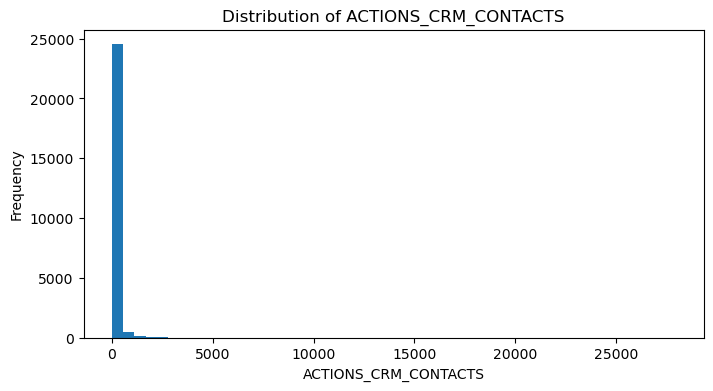

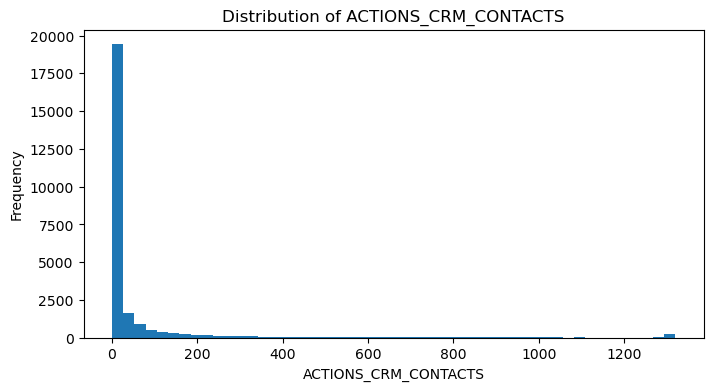

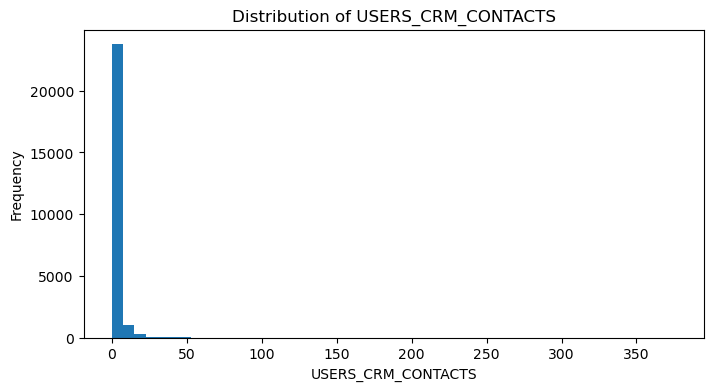

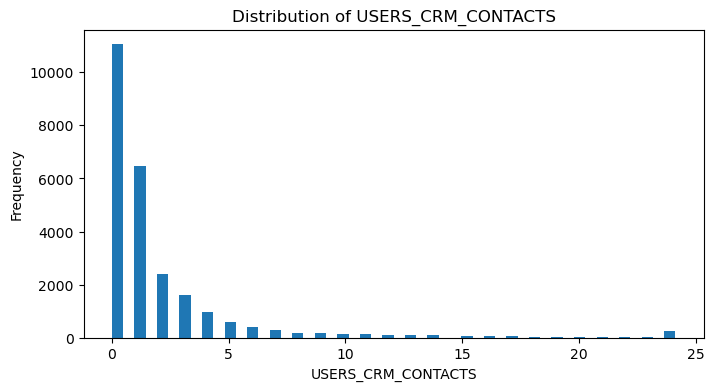

In [6]:
# Plot distributions of the Usage
plot_column_distribution(usage_actions_df, "ACTIONS_CRM_CONTACTS")
plot_column_distribution(usage_actions_df, "ACTIONS_CRM_CONTACTS", clip_quantile=0.99)

plot_column_distribution(usage_actions_df, "USERS_CRM_CONTACTS")
plot_column_distribution(usage_actions_df, "USERS_CRM_CONTACTS", clip_quantile=0.99)

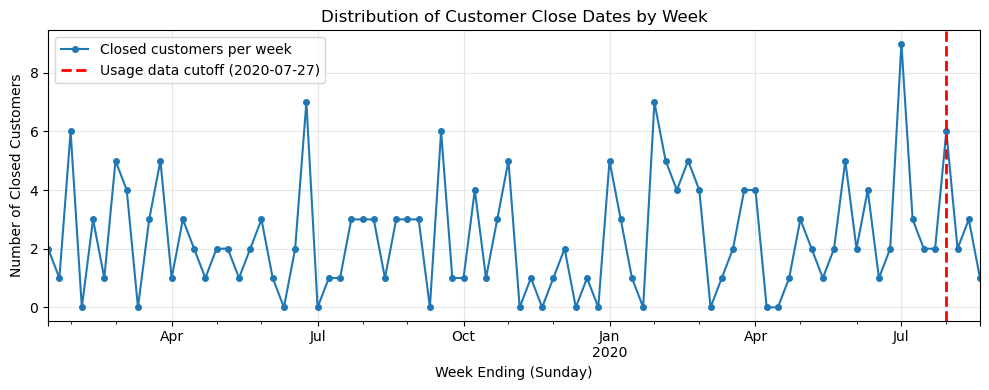

Conversion rate (customers / total companies): 3.8%


In [7]:
# Distribution of customer close dates — helps understand temporal density of positives

# Get cutoff date
cutoff_date = usage_actions_df['WHEN_TIMESTAMP'].max()

fig, ax = plt.subplots(figsize=(10, 4))

# Plot weekly closes with label
customers_df.set_index('CLOSEDATE').resample('W')['ID'].count().plot(
    ax=ax, marker='o', ms=4, label='Closed customers per week')

# Add vertical cutoff line with label
ax.axvline(cutoff_date, linestyle='--', linewidth=2, color='red', label=f'Usage data cutoff ({cutoff_date.date()})')

# Add legend
ax.legend()

ax.set_title('Distribution of Customer Close Dates by Week')
ax.set_xlabel('Week Ending (Sunday)')
ax.set_ylabel('Number of Closed Customers')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Conversion rate (customers / total companies): "
    f"{len(cust_ids) / (len(cust_ids) + len(noncust_ids)):.1%}"
)

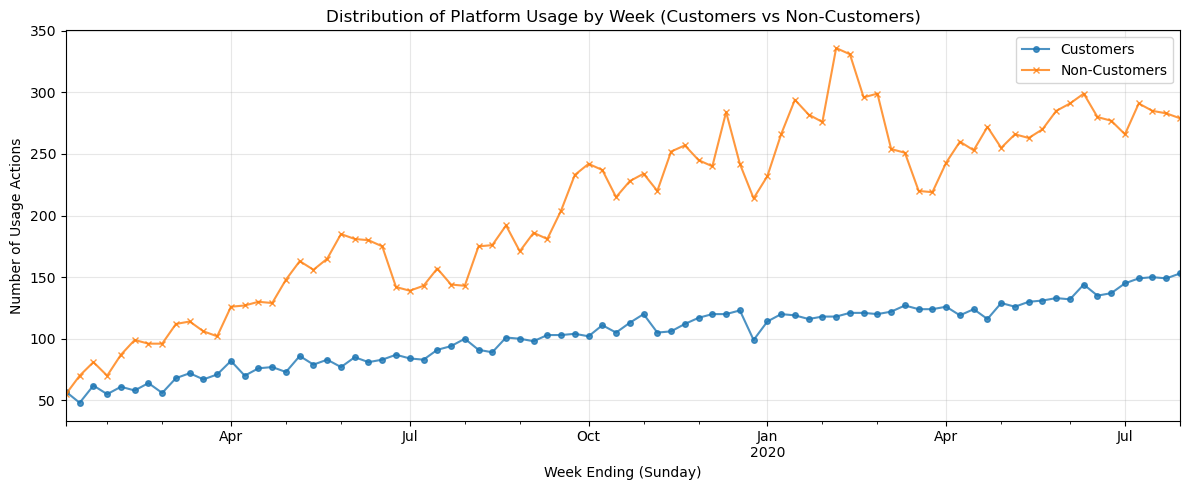

Total usage actions (Customers): 8,464
Total usage actions (Non-Customers): 16,923


In [8]:
# Distribution of platform usage — differentiated by customers and non-customers
fig, ax = plt.subplots(figsize=(12, 5))

# Filter usage for each group
usage_cust = usage_actions_df[usage_actions_df['ID'].isin(cust_ids)]
usage_noncust = usage_actions_df[usage_actions_df['ID'].isin(noncust_ids)]

# Plot weekly usage counts
usage_cust.set_index('WHEN_TIMESTAMP').resample('W')['ID'].count().plot(
    ax=ax, label='Customers', marker='o', ms=4, alpha=0.8
)
usage_noncust.set_index('WHEN_TIMESTAMP').resample('W')['ID'].count().plot(
    ax=ax, label='Non-Customers', marker='x', ms=4, alpha=0.8
)

ax.set_title('Distribution of Platform Usage by Week (Customers vs Non-Customers)')
ax.set_xlabel('Week Ending (Sunday)')
ax.set_ylabel('Number of Usage Actions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total usage actions (Customers): {len(usage_cust):,}")
print(f"Total usage actions (Non-Customers): {len(usage_noncust):,}")

In [9]:
# Usage-level comparison: customers vs non-customers
usage_customers_df = usage_actions_df[usage_actions_df["ID"].isin(cust_ids)].copy()
usage_noncustomers_df = usage_actions_df[usage_actions_df["ID"].isin(noncust_ids)].copy()

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

usage_customer_profile = ProfileReport(usage_customers_df, title="Customer Usage", minimal=True)
usage_noncustomer_profile = ProfileReport(usage_noncustomers_df, title="Non-customer Usage", minimal=True)

usage_customer_profile.compare(usage_noncustomer_profile).to_file(reports_dir / "usage_comparison.html")

display(IFrame(src=str(reports_dir / "usage_comparison.html"), width="100%", height=600))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 2364.05it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 1926.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Company-level comparison: customers vs non-customers
historical_customers_df = customers_df[customers_df["CLOSEDATE"] <= REF_DATE].copy()

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

customer_profile    = ProfileReport(historical_customers_df, title="Customers",     minimal=True)
noncustomer_profile = ProfileReport(noncustomers_df,         title="Non-customers", minimal=True)

customer_profile.compare(noncustomer_profile).to_file(reports_dir / "company_comparison.html")

display(IFrame(src=str(reports_dir / "company_comparison.html"), width="100%", height=600))

c:\Users\totic\anaconda3\Lib\site-packages\ydata_profiling\compare_reports.py:191: UserWarning: The datasets being profiled have a different set of columns. Only the left side profile will be calculated.
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 1322.64it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 313.23it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Main Takeaways from the Analysis

### 1. Company Profile Differences
*   **Size Matters:** Converting customers are typically slightly larger. They are most frequently in the **6–50 employee range** (especially 6–10 employees). Non-customers skew heavily towards very small teams (1–5 employees), with **13.4%** having just 1 employee (vs. only 0.5% for customers).
*   **Industry Focus:** **Computer Software** and **Technology** companies are much more likely to convert. `COMPUTER_SOFTWARE` accounts for ~20% of customers compared to ~16% of non-customers.
*   **Web Presence:** Customers have significantly better web traffic. The median **Alexa Rank** for customers is **3.7M**, whereas for non-customers it is **16M** (often indicating no ranked website). This suggests established businesses with active online footprints are better prospects.

### 2. Usage Behavior
*   **Highly skewed data:** Checking the usage data, the distributions show a very long tail for **all** columns.
    *   **Feature Engineering:** Some capping using methods like IQR/Percentile will be needed in next steps to remove possible outliers.

*   **Massive Activity Gap:** Customers are exponentially more active in the product.
    *   **CRM Contacts:** Customers perform ~15x more actions (223 vs. 15 avg).
    *   **CRM Deals:** Customers perform ~13x more actions (75 vs. 6 avg).
    *   **CRM Companies:** Customers perform ~10x more actions (46 vs. 5 avg).
*   **Team Adoption:** The most critical differentiator is likely **multi-user adoption**. Customers average **~5.3 users** interacting with contacts, whereas non-customers average **<1 user** (0.7).
*   **Feature Usage:**
    *   **Contacts** is the "gateway" feature: only 18% of customers have zero usage here, compared to 56% of non-customers.
    *   **Email** is a power-user feature: while usage is generally lower, customers are 20x more active with email features than non-customers.

### Summary
The ideal conversion candidate is a **Tech/Software company with 6–50 employees** that has **integrated the CRM into their team workflow** (5+ users) and is actively managing a high volume of **Contacts and Deals**. Single-user accounts with low data entry are unlikely to convert.

-----------------------------------------------------------
# 5. Feature Engineering
+ INDUSTRY nulls could be reduced by doing Web Scraping or buying a company industry database
+ Employee range to the middle of the range
+ Standardizing INDUSTRY
+ Cap usage columns using IQR
+ Build date features

In [11]:
# Concat customers and non-customers
companies_df = pd.concat([customers_df, noncustomers_df], axis=0, ignore_index=True)

# Force specific critical types (like Datetime) if convert_dtypes is too conservative
companies_df['CLOSEDATE'] = pd.to_datetime(companies_df['CLOSEDATE'], errors='coerce')

print(f"Merged companies_df shape: {companies_df.shape}")

Merged companies_df shape: (5203, 6)


In [12]:
# For null ALEXA_RANK assume they were not found and page-rank will be weak
companies_df['ALEXA_RANK'] = np.where(companies_df['ALEXA_RANK'].isnull(), companies_df['ALEXA_RANK'].max() + 1, companies_df['ALEXA_RANK'])

# Log-transform Alexa Rank: the rank signal is logarithmic, this helps linear models (LogisticRegression) capture the signal correctly.
companies_df['ALEXA_RANK_LOG'] = np.log1p(companies_df['ALEXA_RANK'])

In [13]:
# Employee range to numeric midpoint
companies_df["EMPLOYEE_RANGE"] = companies_df["EMPLOYEE_RANGE"].map(EMPLOYEE_RANGE_TO_MID)

In [14]:
# Clean Industry column
companies_df = clean_industry_column(companies_df, 'INDUSTRY')

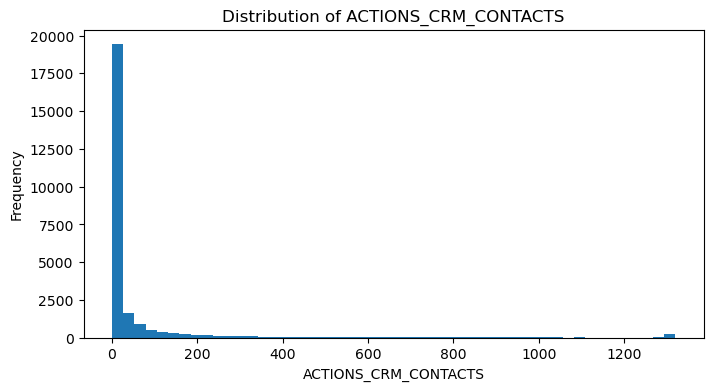

In [15]:
# Cap usage columns using 99th percentile value to cap the long tails 
usage_actions_df = cap_outliers(usage_actions_df, columns=METRIC_COLS, method="percentile", lower_pct=0.00, upper_pct=0.99)

# Display the plot of usage again - Much better now!
plot_column_distribution(usage_actions_df, "ACTIONS_CRM_CONTACTS")

## Backtesting & Leakage Prevention Strategy

This project uses a **Point-in-Time (PIT) Expanding Window Backtest** to simulate exactly what would have happened if the model were running in production on specific past dates. This is the gold standard for time-series forecasting to ensure realistic performance estimates.

### 1. The Backtesting Framework
Instead of a random train/test split (which would fail due to time dependency), we simulate 6 historical "production runs" (cutoffs) spaced 1 month apart.

*   **Cutoffs:** Sundays from Feb 2020 to July 2020.
*   **Training Set:** All data available *strictly before* the cutoff.
*   **Test Set:** The 30-day window *immediately following* the cutoff.
*   **Expanding Window:** As time moves forward, the training set grows (incorporating more history), while the test set moves forward to the next month.

### 2. Preventing Feature Leakage (The "Time Travel" Problem)
Feature leakage occurs when the model accidentally sees data from the future. We prevent this via **Point-in-Time Feature Construction** in `src/features.py`.

*   **Strict Temporal Filtering:** For every cutoff, we filter the raw usage logs to keep only rows where `WHEN_TIMESTAMP < cutoff`.
*   **Rolling Windows:** Features like `actions_sum_30d` are calculated relative to the specific cutoff date.
    *   *Example:* For the `2020-04-01` cutoff, the 30-day window is `2020-03-02` to `2020-04-01`. Usage on `2020-04-02` is invisible.
*   **Recency Calculations:** Derived features like `days_since_last_usage` are computed as `cutoff - last_usage_date`. This ensures the recency score reflects the state of the user *at that moment in time*.

### 3. Preventing Label Leakage
Label leakage happens when the training data contains information about the target variable that wouldn't be available in production.

*   **Test Positives Excluded from Training:** Companies that *will* convert in the next 30 days (the test positives) are **removed** from the training set.
    *   *Why?* If we left them in as "negatives" (since they haven't converted *yet*), we would be teaching the model that "high-potential companies are negatives," confusing the decision boundary.
*   **Training Positive Window:** We only label a company as a "training positive" if they converted within the **90 days prior to the cutoff**.
    *   *Why?* A company that converted 2 years ago has a mature, stable usage profile (long tenure, high total actions). A company *about* to convert has a different profile (accelerating usage, recent signup). Training on old converters creates "Mature Customer Bias," where the model learns to identify long-term customers rather than new prospects.

### 4. Preventing Pipeline Leakage
Data processing steps must not "peek" at the test set statistics.

*   **Isolated Pipelines:** We use `sklearn.pipeline.Pipeline` for every model.
*   **Fit/Transform Separation:**
    *   **Imputers (Median):** The median value for missing data is calculated *only* on the training set and applied to the test set.
    *   **Scalers (StandardScaler):** Mean and variance are learned *only* from training data.
    *   **Feature Selection (RFE):** The Recursive Feature Elimination selects the top 30 features based *only* on training correlations.
    *   *Result:* The test set is treated as completely unseen "future" data, just like in a real production environment.

In [ ]:
# Generate Features from Usage with cutoffs for Backtesting
feat_backtester = VectorizedUsageFeatureBacktester(
                                                    usage_actions_df, 
                                                    companies_df,
                                                    action_cols=ACTION_COLS, 
                                                    user_cols=USER_COLS,
                                                    windows=WINDOWS, 
                                                    n_cutoffs=6)

features = feat_backtester.build().reset_index()
print(f"Feature panel shape: {features.shape}")

In [ ]:
usage_actions_df.describe()

In [ ]:
features[features['ID']==67] # Conversion date in 2020-07-15

In [ ]:
usage_actions_df[usage_actions_df['ID']==67]

-----------------------------------------
# 6. Modeling

## Model Choice Rationale

We train three models and combine them into a soft-voting ensemble ("Metamodel"):

- **Logistic Regression** — Linear baseline with high interpretability; benefits from the log-transformed Alexa rank and scaled features.
- **Random Forest** — Captures non-linear interactions (e.g., high usage + small team); robust to outliers; provides RFE feature importances.
- **LightGBM** — Best performer on tabular data with class imbalance; handles missing values natively.
- **Soft-Voting Ensemble (Metamodel)** — Averages calibrated probabilities across all three. Reduces variance from any single model's instability across small folds.

## Feature Selection: RFE

RFE (Recursive Feature Elimination) is run **separately per model pipeline**. This is intentional and correct:
- Each model type may benefit from a different feature subset (e.g., LR benefits from removing correlated features; tree models are more robust to them).
- Fitting a shared RFE mask on training data and applying to all models would reduce model diversity in the ensemble.
- The RFE itself is fit only on training data — there is no leakage.
- Results with and after RFE improved by 10.9%.

## Handling Class Imbalance

With ~3.8% conversion rate, class imbalance is handled at the algorithm level:
- `class_weight='balanced'` for RF and LR
- `is_unbalance=True` for LightGBM

SMOTE was considered but not applied for the following reasons:
- With only 8–17 true positives per test fold, SMOTE on the training set introduces synthetic samples that may not represent actual conversion behavior.
- SMOTE must be applied inside the pipeline per-fold to avoid leakage from test set distribution.
- The algorithm-level balancing achieves similar effect with less risk on this dataset size.
- With more data (larger customer base), SMOTE inside an `imblearn` Pipeline would be a worthwhile addition.

## Evaluation Metric Rationale

For a **sales outreach use case**, the primary metric is **Precision@K** (are the top K leads actually converters?), because:
- Sales rep time is the scarce resource — a false positive (calling a non-converter) wastes a rep's time.
- At early funnel stage, missing some converters (lower recall) is acceptable if those contacted have high precision.
- We also track **Recall@K** and **ROC-AUC** for completeness and to detect degenerate models.
- **PR-AUC** is reported over ROC-AUC as the primary curve metric, since ROC-AUC is optimistic with severe class imbalance.
- Cross-validation was discarded due to the small number of samples available per split, making results unstable.

## Definition of Positive Examples

The business ask is:
> "prioritizing their outreach for prospective companies that have a free portal, but have not yet converted into paying customers and are likely to do so within the next 30 days"

Positive examples are therefore defined as **free-tier companies that convert within the next 30 days from the scoring cutoff**.

Two approaches were evaluated for defining training positives:

1. **All historical converters (chosen)** — Any company that converted on or before the cutoff is a positive. The model learns what a converting company looks like across the full history of conversions, maximising training signal given the small dataset (~200 total converters).

2. **Recently-converted only (discarded for now)** — Only companies that converted within a short window before the cutoff (e.g., 90 days) are marked positive. This is theoretically preferable: it teaches the model what a company looks like *in the weeks immediately before conversion*, rather than what a long-tenured customer looks like — the two profiles can differ significantly. However, with only ~200 total converters this reduces training positives to ~25–50 per fold, making the model unstable. This approach was tested and confirmed to degrade performance on this dataset. **It is the recommended approach in production**, where a larger customer base would provide sufficient positive examples per fold to train reliably.


In [ ]:
# Initialize backtester, main class for forecast
backtester = PropensityBacktester(
    companies_df=companies_df, 
    customers_df=customers_df, 
    features_df=features,
    prediction_horizon_days=30,
    top_k_leads=10,
    n_features_to_select=30,
    company_drop_cols=["CLOSEDATE", "MRR", "INDUSTRY", "ALEXA_RANK"],  # drop raw rank, keep log version
    training_positive_window_days=None # All historical positive samples go into the trainig, else applies preconversion filter
)

# metrics_summary: contains the scores for the plots
# lead_priority_table: the production list for the sales team
metrics_summary, lead_priority_table = backtester.run_backtest()

backtester.plot_results()

# Inspect the top 10 leads for the most recent cutoff
recent_leads = lead_priority_table[lead_priority_table['cutoff'] == lead_priority_table['cutoff'].max()].head(10)
print("\n--- SAMPLE SALES CALL LIST (Top 10) ---")
print(recent_leads[['company_id', 'propensity_score', 'priority_rank']])

## Baseline Comparison

To interpret model performance, we compare against two naive baselines:

- **Random Baseline**: Randomly ranks all non-converted companies. Expected P@K = prevalence rate.
- **Most Active Baseline**: Ranks companies by total raw action count in the last 30 days. A simple heuristic a business analyst could build without ML, sown in Activity P@10.


If our models cannot beat the activity-based heuristic, they provide no marginal value.

In [ ]:
# Run baselines for comparison
baseline_df = EvaluationMixin.run_baselines(backtester, top_k=10)

# Also pull the Metamodel results for comparison
meta_rows = []
for fold in metrics_summary:
    for m in fold['metrics']:
        if m['model'] == 'Metamodel':
            meta_rows.append({'cutoff': fold['cutoff'], 'meta_p_at_k': m['p_at_k'], 'meta_rec_at_k': m['rec_at_k']})
meta_df = pd.DataFrame(meta_rows)

comparison_df = baseline_df.merge(meta_df, on='cutoff')

print("\n=== Baseline vs. Metamodel Comparison (P@10) ===")
print(f"{'Cutoff':<14} | {'Prevalence':>10} | {'Random P@10':>11} | {'Activity P@10':>13} | {'Metamodel P@10':>14}")
print("-" * 70)
for _, row in comparison_df.iterrows():
    print(f"{str(row['cutoff'].date()):<14} | {row['prevalence']:>10.2%} | "
          f"{row['random_p_at_k']:>11.2f} | {row['active_p_at_k']:>13.2f} | {row['meta_p_at_k']:>14.2f}")

# Averaged lift over random
avg_random = comparison_df['random_p_at_k'].mean()
avg_active = comparison_df['active_p_at_k'].mean()
avg_meta   = comparison_df['meta_p_at_k'].mean()
print(f"\nAVERAGE P@10 — Random: {avg_random:.2f} | Activity Heuristic: {avg_active:.2f} | Metamodel: {avg_meta:.2f}")
print(f"Lift vs. Random:   {avg_meta / avg_random:.1f}x" if avg_random > 0 else "")
print(f"Lift vs. Activity: {avg_meta / avg_active:.1f}x" if avg_active > 0 else "")

## Precision-Recall Curves

**Why PR curves over ROC?**  
With ~3.8% conversion rate, ROC-AUC is misleadingly optimistic. A model can achieve 0.85 ROC-AUC while having near-random precision at the thresholds that matter. PR curves reveal this by plotting precision vs. recall directly across all decision thresholds.

**Interpreting for sales outreach:**
- The operating point (threshold choice) depends on how many leads the sales team can realistically call per week.
- If the team can call 20 leads/week, we read precision at the recall level that covers ~20 companies.
- A higher area under the PR curve (PR-AUC, also called Average Precision) means better performance across all thresholds.

We plot curves for the **most recent fold** where test positives are highest (most reliable estimate).

In [ ]:
# PR Curve
PropensityBacktester.plot_pr_curves_for_fold(backtester, top_k=20)

## Feature Importance

We extract feature importances from the LightGBM model (most recent fold) after RFE selection. This answers the business question: **what signals actually drive conversion propensity?**

This is also directly useful for the sales team: top features indicate what reps should look for when qualifying leads manually.

In [ ]:
# Feature importance of the model
feature_imp_df = PropensityBacktester.plot_feature_importance(backtester, n_top=20)

## SHAP Analysis

Gain-based feature importance (above) tells us which features the model uses *globally*. SHAP (SHapley Additive exPlanations) tells us *why each individual company* received its score — the contribution of every feature to that specific prediction.

This matters for two reasons:

1. **Stakeholder trust** — A sales rep who understands *why* a company is ranked #1 is far more likely to act on the list than one who sees a black-box score.
2. **Actionability** — SHAP values enable a `top_feature_signal` column in the weekly output: a one-line human-readable explanation per lead (e.g., *"High Deals activity (60d) + 400 days on free tier"*).

We produce three SHAP outputs:
- **Beeswarm plot** — global view of how each feature drives scores up or down across all test companies. Each dot is one company; red = high feature value, blue = low. Positive X-axis = pushes toward conversion.
- **Waterfall plot** — deep-dive on the single highest-ranked lead, showing exactly how each feature contributed to its score from the base rate up.
- **Enriched sales list** — top SHAP driver per company appended as a human-readable `top_feature_signal` column, making the weekly list directly actionable for reps without ML knowledge.

In [ ]:
# Execute SHAP analysis for explainability
lead_table_with_signals, shap_values_df = PropensityBacktester.run_shap_analysis(backtester, lead_priority_table)

In [ ]:
# ── Weekly Sales Output ──────────────────────────────────────────────────────
# Production deliverable: the ranked list the sales team acts on every Sunday.
# signal_1/2/3 columns are now populated for every company across all folds.

most_recent_cutoff = lead_table_with_signals["cutoff"].max()

sales_output = (
    lead_table_with_signals[lead_table_with_signals["cutoff"] == most_recent_cutoff]
    .sort_values("priority_rank")
    [["priority_rank", "company_id", "propensity_score", "converted_actual", "signal_1", "signal_2", "signal_3"]]
    .reset_index(drop=True)
)

# Merge company metadata for sales context
company_meta = companies_df[["ID", "EMPLOYEE_RANGE", "ALEXA_RANK", "INDUSTRY"]].copy()
sales_output = (
    sales_output
    .merge(company_meta, left_on="company_id", right_on="ID", how="left")
    .drop(columns="ID")
)

# Round score for readability
sales_output["propensity_score"] = sales_output["propensity_score"].round(3)

# In production, converted_actual is unknown at scoring time.
# Rename to clarify it is filled in 30 days later for monitoring.
sales_output = sales_output.rename(columns={"converted_actual": "converted_30d_actual"})
sales_output["converted_30d_actual"] = sales_output["converted_30d_actual"].replace({0: "", 1: "YES"})

# Show top 20
print(f"Weekly Sales Call List — Cutoff: {most_recent_cutoff.date()}")
print(f"Total non-customers scored: {len(sales_output)}")
print(f"\nTop 20 leads:\n")
pd.set_option("display.max_colwidth", 55)
display(sales_output.head(20))

# Verify signals populated correctly
n_missing = sales_output["signal_1"].isin(["", "No signal computed"]).sum()
print(f"\nSignal coverage: {len(sales_output) - n_missing}/{len(sales_output)} leads have a signal_1")

# Save full ranked list
output_path = f"../reports/sales_call_list_{most_recent_cutoff.date()}.csv"
sales_output.to_csv(output_path, index=False)
print(f"Full list ({len(sales_output)} companies) saved to: {output_path}")

## LLM Enriched SHAP

In [ ]:
# ── LLM Enrichment ───────────────────────────────────────────────────────────
# Runs on top 20 leads only to keep token usage low.
# Requires OPENAI_API_KEY in ../.env

load_dotenv('../.env')
api_key = os.getenv("OPENAI_API_KEY")

if api_key and api_key != "your_api_key_here":
    print("Enriching top 20 leads with GenAI explanations...")
    agent = SalesIntelligenceAgent(api_key=api_key)

    # Slice top 20 leads
    top_20_enriched = agent.generate_sales_briefs(sales_output.head(20).copy())

    # Initialize column
    sales_output["llm_sales_brief"] = ""

    # Write back only top 20 rows
    sales_output.loc[top_20_enriched.index, "llm_sales_brief"] = top_20_enriched["llm_sales_brief"]
    print(f"✓ {len(top_20_enriched)} explanations generated")

else:
    print("Skipping LLM enrichment — set OPENAI_API_KEY in ../.env to enable")
    sales_output["llm_sales_brief"] = "LLM enrichment skipped"

sales_output

In [ ]:
sales_output['llm_sales_brief'].unique()

-----------------
# 7. Production Deployment Plan

The problem requires generating a **weekly prioritized list every Sunday**. Below is how this model would transition from backtest to production.



## Retraining Strategy

**Expanding window retraining (recommended for this dataset size):**
- Each Sunday, retrain the model using **all historical data available** up to Saturday (the cutoff).
- Label positives as: companies that converted at any point in the past.
- Label the test set (this week's scoring) as all current free-tier portals.
- This is the safest approach given the small dataset (~200 customers). A rolling window would reduce training size further.

**Retraining frequency:** Weekly, triggered on Sunday mornings via a scheduled job (cron / Airflow / dbt).



## Pipeline Steps (Sunday Job)

```
1. Pull usage_actions WHERE WHEN_TIMESTAMP >= (today - 90 days)  ← rolling usage window
2. Pull current noncustomers (free-tier portals with no CLOSEDATE)
3. Pull all historical customers (for training labels)
4. Run VectorizedUsageFeatureBacktester.build() at cutoff = Sunday
5. Encode company static features (INDUSTRY, EMPLOYEE_RANGE, ALEXA_RANK)
6. Fit PropensityBacktester on all available training data
7. Score all active non-customers
8. Output top-K prioritized list → CRM / Salesforce / HubSpot Deals
```



## Cold-Start Problem

New portals (< 7 days of usage) have no meaningful rolling features. Options:
- **Exclude** from scoring until they have ≥ 14 days of usage data.
- **Fallback to static features only** (company size, industry, Alexa rank) with a lower-confidence score.
- Flag as `cold_start=True` in the output list so reps know the score is less reliable.


## Feedback Loop

Model performance degrades without ground truth feedback:
- **Log every scored company and its rank** at each Sunday cutoff.
- **30 days later**, join back to the customer table to check if they converted.
- Use this to compute real P@K weekly and alert if performance degrades >20% from backtest baseline.
- **Sales rep feedback** (e.g., 'this lead was unqualified') can be used as additional negative labels.



## Model Monitoring

Key signals to monitor in production:
- **Propensity score distribution shift** — if the average score drifts significantly, features may have changed.
- **Feature drift** — monitor mean/std of top features (e.g., `actions_sum_30d`) week-over-week.
- **Conversion rate stability** — if the actual weekly conversion rate drops significantly, the model needs retraining with a recency bias.



## Output Format for Sales Team

The final weekly output table should contain:

| company_id | company_name | propensity_score | priority_rank | employee_range | industry | days_since_last_usage | top_feature_signal |
|---|---|---|---|---|---|---|---|
| 4521 | Acme Corp | 0.82 | 1 | 26-50 | TECH | 2 | High Deals usage (30d) |

The `top_feature_signal` column (a human-readable explanation of the top driver) can be derived from LightGBM SHAP values and makes the list directly actionable for reps without requiring ML knowledge.